# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [19]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load ratings

In [20]:
transformer_ratings = pd.read_csv("generated/ratings/player_contributions_match_3943043_transformer.csv")
print(transformer_ratings.columns)
transformer_ratings.head()

Index(['total_value', 'num_sequences', 'avg_value', 'max_value', 'player_id', 'player_name', 'team_name'], dtype='object')


,total_value,num_sequences,avg_value,max_value,player_id,player_name,team_name
0,1.720473,102,0.016867,0.179595,68574,Nicholas Williams Arthuer,Spain
1,1.222608,71,0.017220,0.919108,3943,Declan Rice,England
2,0.817241,75,0.010897,0.187941,316046,Lamine Yamal Nasraoui Ebana,Spain
3,0.798686,125,0.006389,0.185811,6655,Fabián Ruiz Peña,Spain
4,0.682922,77,0.008869,0.180763,3205,Kyle Walker,England


In [21]:
attention_lstm_ratings = pd.read_csv("generated/ratings/player_contributions_match_3943043_attention_lstm.csv")
attention_lstm_ratings.head()

,total_value,num_sequences,avg_value,max_value,player_id,player_name,team_name
0,1.242785,102,0.012184,0.118721,68574,Nicholas Williams Arthuer,Spain
1,0.962968,125,0.007704,0.055847,6655,Fabián Ruiz Peña,Spain
2,0.776907,126,0.006166,0.050386,5721,Daniel Carvajal Ramos,Spain
3,0.709577,70,0.010137,0.035139,16532,Daniel Olmo Carvajal,Spain
4,0.660164,152,0.004343,0.058445,4353,Aymeric Laporte,Spain


In [22]:
sofascore_rating = pd.read_csv("generated/ratings/sofacore.csv")
sofascore_rating

,player_name,team_name,Pozycja,sofascore_rating
0,Nicholas Williams Arthuer,Spain,Pomocnik,7.9
1,Jude Bellingham,England,Pomocnik,7.7
2,Lamine Yamal Nasraoui Ebana,Spain,Pomocnik,7.5
3,Mikel Oyarzabal Ugarte,Spain,Napastnik,7.5
4,Fabián Ruiz Peña,Spain,Pomocnik,7.4
5,Jordan Pickford,England,Bramkarz,7.4
6,Cole Palmer,England,Napastnik,7.3
7,Marc Cucurella Saseta,Spain,Obrońca,7.1
8,Aymeric Laporte,Spain,Obrońca,7.0
9,Martín Zubimendi Ibáñez,Spain,Pomocnik,7.0


## 2. Analysis


In [51]:
# Merge all ratings
attention_lstm_prep = attention_lstm_ratings[['player_name', 'team_name', 'total_value']].rename(columns={
    'total_value': 'attention_lstm_total_value',
})

transformer_prep = transformer_ratings[['player_name', 'team_name', 'total_value', 'num_sequences']].rename(columns={
    'total_value': 'transformer_total_value',
})

sofascore_prep = sofascore_rating[['player_name', 'team_name', 'sofascore_rating']]

# Merge all dataframes
all_ratings = attention_lstm_prep.merge(
    transformer_prep,
    on=['player_name', 'team_name'],
    how='outer'
).merge(
    sofascore_prep,
    on=['player_name', 'team_name'],
    how='outer'
)

# Convert num_sequences columns to int
all_ratings['num_sequences'] = all_ratings['num_sequences'].astype(int)

# Sort by attention_lstm_total_value
all_ratings = all_ratings.sort_values('attention_lstm_total_value', ascending=False)

all_ratings.style.hide(axis='index')

player_name,team_name,attention_lstm_total_value,transformer_total_value,num_sequences,sofascore_rating
Nicholas Williams Arthuer,Spain,1.242785,1.720473,102,7.900000
Fabián Ruiz Peña,Spain,0.962968,0.798686,125,7.400000
Daniel Carvajal Ramos,Spain,0.776907,0.665989,126,6.700000
Daniel Olmo Carvajal,Spain,0.709577,0.506555,70,6.900000
Aymeric Laporte,Spain,0.660164,0.568710,152,7.000000
Robin Aime Robert Le Normand,Spain,0.658067,0.431317,153,6.900000
Lamine Yamal Nasraoui Ebana,Spain,0.571512,0.817241,75,7.500000
Declan Rice,England,0.531927,1.222608,71,6.800000
Jude Bellingham,England,0.528454,0.468874,66,7.700000
Bukayo Saka,England,0.410017,0.448848,56,6.800000


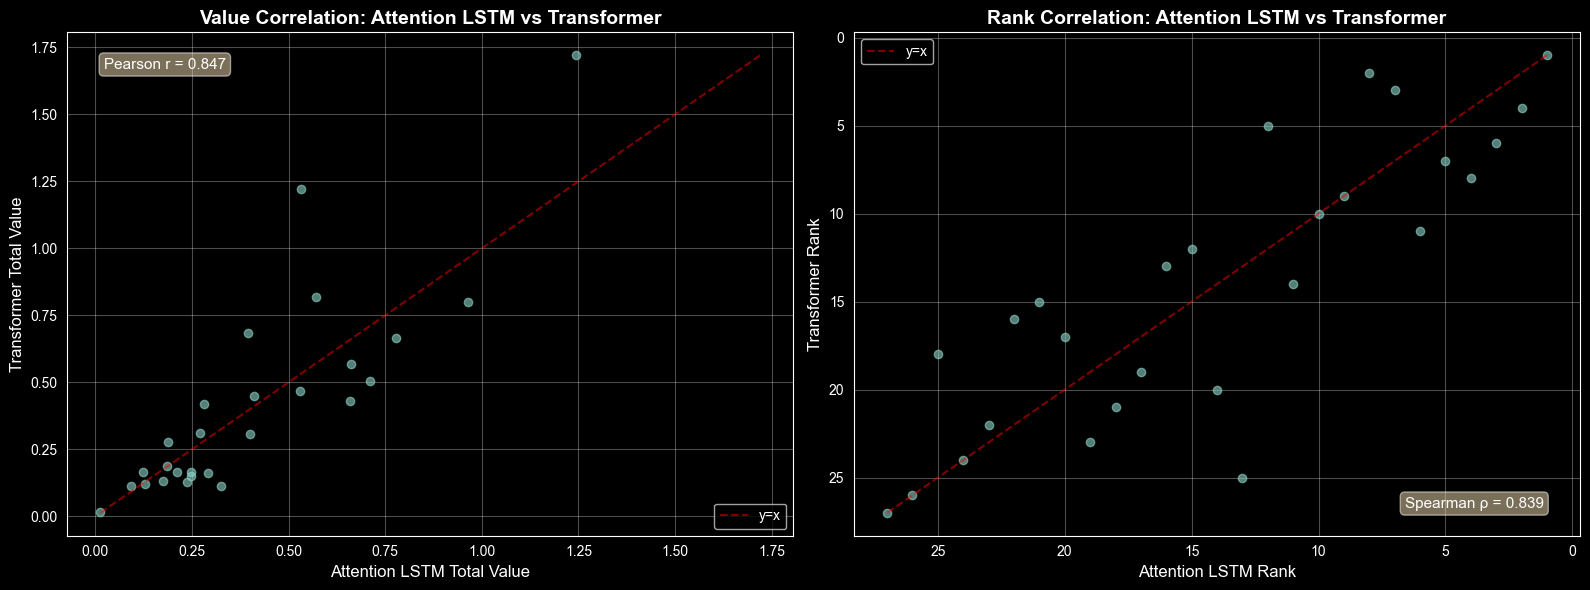


=== Top 10 players: Attention LSTM ranks much higher than Transformer ===
                player_name team_name  attn_rank  tr_rank  rank_diff
                Kyle Walker   England       12.0      5.0        7.0
     Mikel Oyarzabal Ugarte     Spain       25.0     18.0        7.0
                Declan Rice   England        8.0      2.0        6.0
                 Phil Foden   England       21.0     15.0        6.0
              Kobbie Mainoo   England       22.0     16.0        6.0
Lamine Yamal Nasraoui Ebana     Spain        7.0      3.0        4.0
            Jordan Pickford   England       15.0     12.0        3.0
 Álvaro Borja Morata Martín     Spain       16.0     13.0        3.0
                John Stones   England       20.0     17.0        3.0
                 Marc Guehi   England       23.0     22.0        1.0

=== Top 10 players: Transformer ranks much higher than Attention LSTM ===
                 player_name team_name  attn_rank  tr_rank  rank_diff
                 Cole

In [52]:
# Correlation plots: Attention LSTM vs Transformer
df_corr = all_ratings.dropna(subset=['attention_lstm_total_value', 'transformer_total_value']).copy()

# Calculate ranks
df_corr['attn_rank'] = df_corr['attention_lstm_total_value'].rank(ascending=False, method='min')
df_corr['tr_rank'] = df_corr['transformer_total_value'].rank(ascending=False, method='min')
df_corr['rank_diff'] = df_corr['attn_rank'] - df_corr['tr_rank']

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Value correlation
ax1.scatter(df_corr['attention_lstm_total_value'], df_corr['transformer_total_value'], alpha=0.6)
ax1.set_xlabel('Attention LSTM Total Value', fontsize=12)
ax1.set_ylabel('Transformer Total Value', fontsize=12)
ax1.set_title('Value Correlation: Attention LSTM vs Transformer', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add diagonal reference line
min_val = min(df_corr['attention_lstm_total_value'].min(), df_corr['transformer_total_value'].min())
max_val = max(df_corr['attention_lstm_total_value'].max(), df_corr['transformer_total_value'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
ax1.legend()

# Calculate and display Pearson correlation
pearson_corr = df_corr['attention_lstm_total_value'].corr(df_corr['transformer_total_value'])
ax1.text(0.05, 0.95, f'Pearson r = {pearson_corr:.3f}',
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Rank correlation
ax2.scatter(df_corr['attn_rank'], df_corr['tr_rank'], alpha=0.6)
ax2.set_xlabel('Attention LSTM Rank', fontsize=12)
ax2.set_ylabel('Transformer Rank', fontsize=12)
ax2.set_title('Rank Correlation: Attention LSTM vs Transformer', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()  # Lower rank = better
ax2.invert_yaxis()

# Add diagonal reference line
min_rank = min(df_corr['attn_rank'].min(), df_corr['tr_rank'].min())
max_rank = max(df_corr['attn_rank'].max(), df_corr['tr_rank'].max())
ax2.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, label='y=x')
ax2.legend()

# Calculate and display Spearman correlation
spearman_corr = df_corr['attn_rank'].corr(df_corr['tr_rank'], method='spearman')
ax2.text(0.95, 0.05, f'Spearman ρ = {spearman_corr:.3f}',
         transform=ax2.transAxes, fontsize=11, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig("generated/ratings/attention_lstm_vs_transformer_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

# Print players with biggest rank differences
print("\n=== Top 10 players: Attention LSTM ranks much higher than Transformer ===")
top_diff = df_corr.nlargest(10, 'rank_diff')[['player_name', 'team_name', 'attn_rank', 'tr_rank', 'rank_diff']]
print(top_diff.to_string(index=False))

print("\n=== Top 10 players: Transformer ranks much higher than Attention LSTM ===")
low_diff = df_corr.nsmallest(10, 'rank_diff')[['player_name', 'team_name', 'attn_rank', 'tr_rank', 'rank_diff']]
print(low_diff.to_string(index=False))

### diagram visualization of top sequences for a player

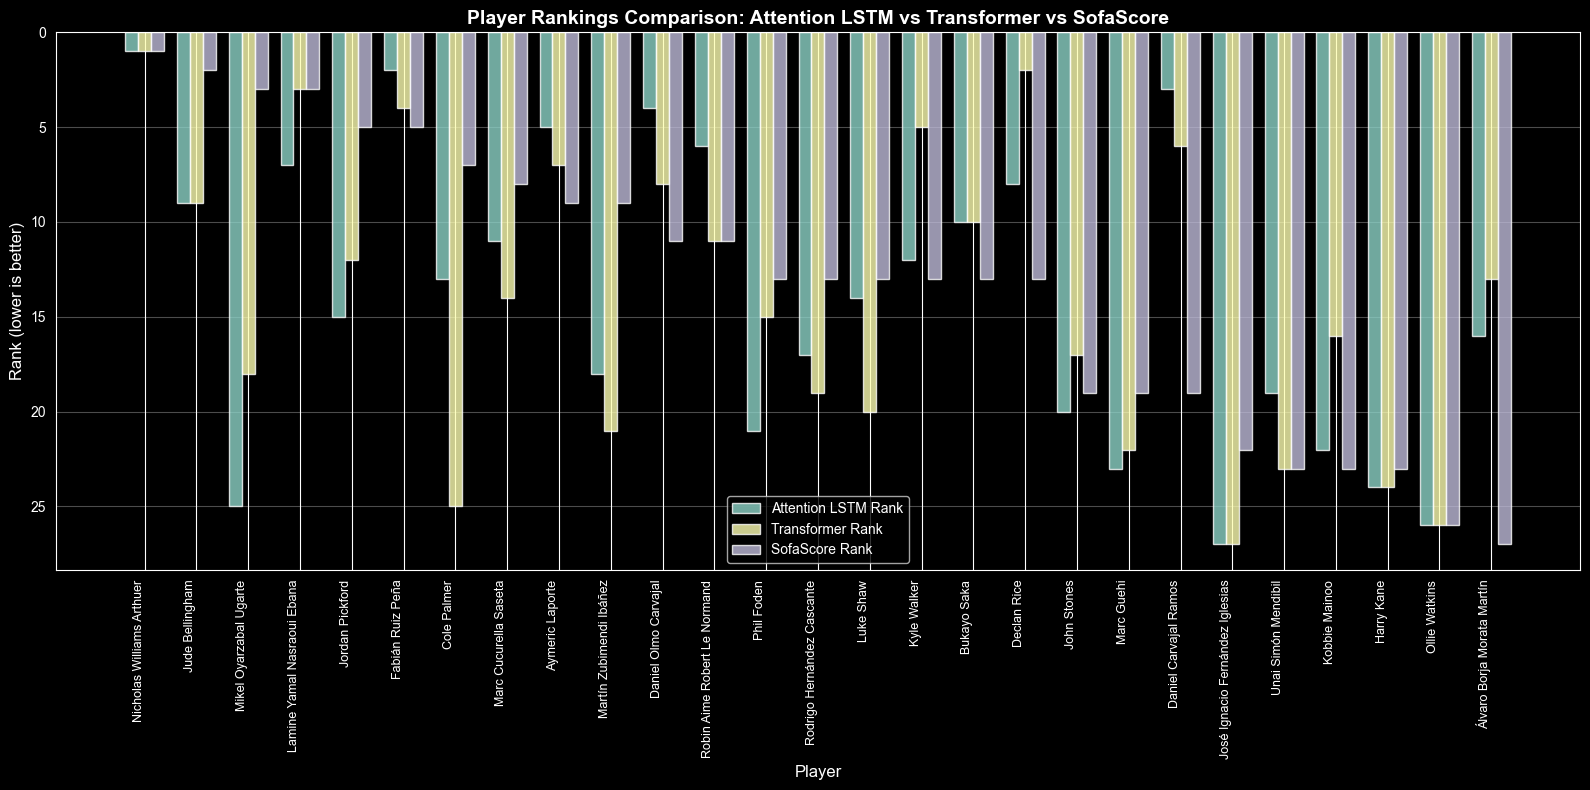

In [42]:
# Prepare data for grouped bar chart
df_plot = all_ratings.copy()

# Create ranks for each rating (lower rank = better)
df_plot['attn_rank'] = df_plot['attention_lstm_total_value'].rank(ascending=False, method='min')
df_plot['tr_rank'] = df_plot['transformer_total_value'].rank(ascending=False, method='min')
df_plot['sofa_rank'] = df_plot['sofascore_rating'].rank(ascending=False, method='min')

# Sort by sofascore_rating
df_plot = df_plot.sort_values('sofascore_rating', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# X-axis positions
x = np.arange(len(df_plot))
width = 0.25

# Create bars for each ranking
bars1 = ax.bar(x - width, df_plot['attn_rank'], width, label='Attention LSTM Rank', alpha=0.8)
bars2 = ax.bar(x, df_plot['tr_rank'], width, label='Transformer Rank', alpha=0.8)
bars3 = ax.bar(x + width, df_plot['sofa_rank'], width, label='SofaScore Rank', alpha=0.8)

# Customize plot
ax.set_xlabel('Player', fontsize=12)
ax.set_ylabel('Rank (lower is better)', fontsize=12)
ax.set_title('Player Rankings Comparison: Attention LSTM vs Transformer vs SofaScore', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['player_name'], rotation=90, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.invert_yaxis()  # Lower rank = better (at top)

plt.tight_layout()
plt.savefig("generated/ratings/player_rank_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

### Save to csv

In [27]:
all_ratings.to_csv("generated/ratings/all_ratings.csv")

In [25]:
all_ratings.columns


Index(['player_name', 'team_name', 'attention_lstm_total_value', 'transformer_total_value', 'num_sequences', 'sofascore_rating'], dtype='object')

### Clean / types

In [32]:
df = all_ratings.copy()
numeric_cols = [
    "attention_lstm_total_value",
    "transformer_total_value",
    "num_sequences",
    "sofascore_rating",
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_f = df.dropna(subset=["player_name", "team_name"] + numeric_cols)

### 3) Normalizations

In [33]:
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    mu, sd = s.mean(), s.std(ddof=0)
    if sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd

for d in [df_f]:
    d["attn_mm"] = minmax(d["attention_lstm_total_value"])
    d["tr_mm"]   = minmax(d["transformer_total_value"])
    d["sofa_mm"] = minmax(d["sofascore_rating"])

    d["attn_z"] = zscore(d["attention_lstm_total_value"])
    d["tr_z"]   = zscore(d["transformer_total_value"])
    d["sofa_z"] = zscore(d["sofascore_rating"])

### 4) Plots

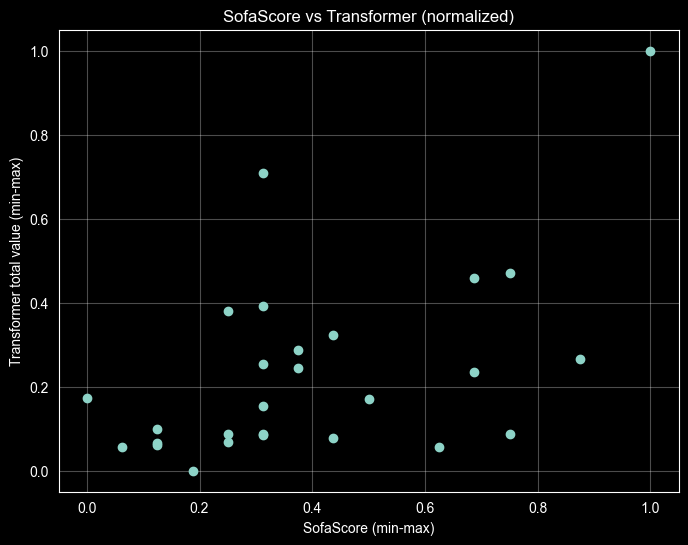

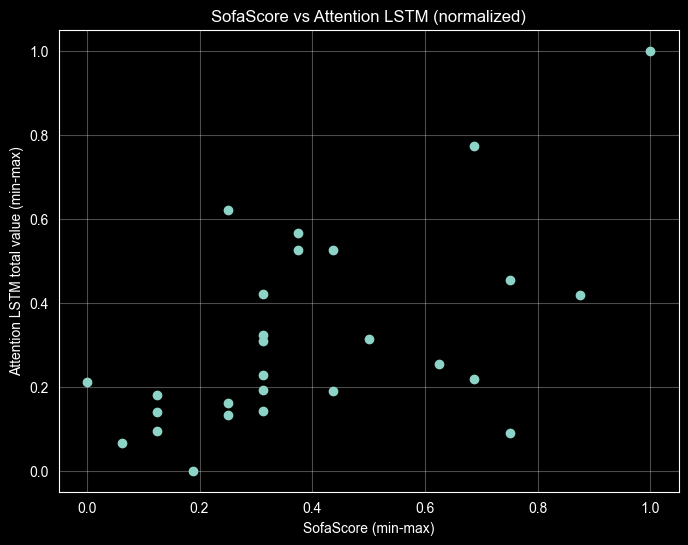

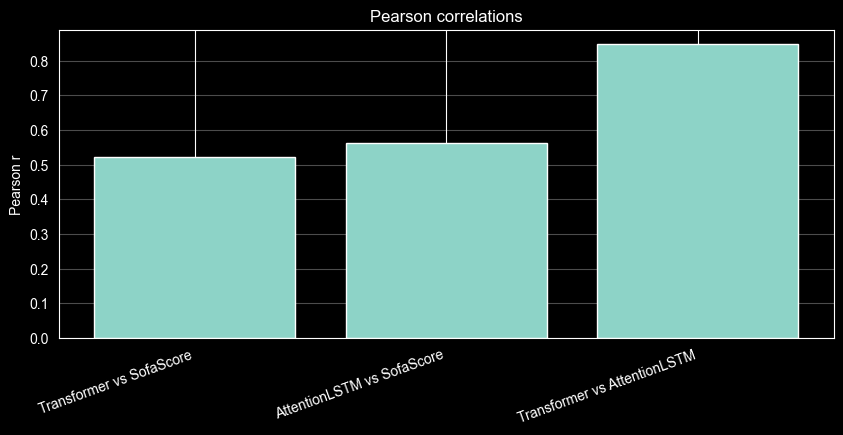

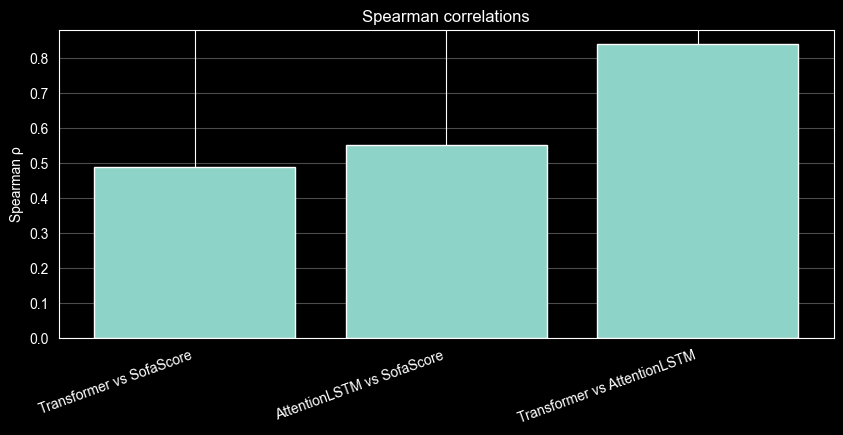

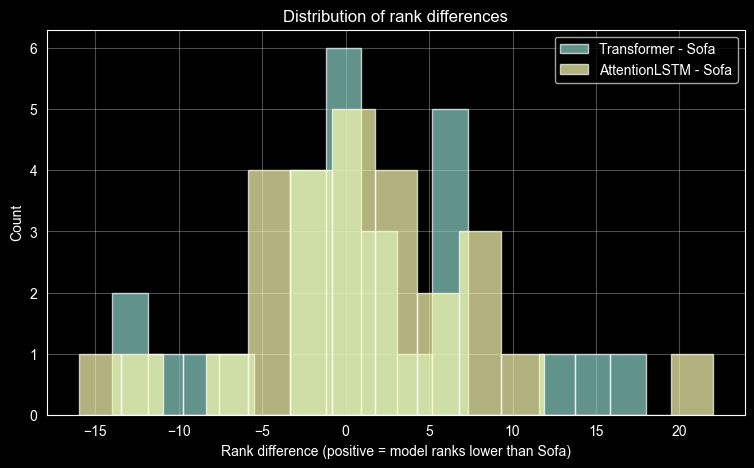


=== Correlations ===
                        pair  pearson  spearman
    Transformer vs SofaScore 0.521066  0.487945
  AttentionLSTM vs SofaScore 0.561755  0.552205
Transformer vs AttentionLSTM 0.847140  0.839438

=== Recall@K (Top-K overlap vs SofaScore) ===
 K  Transformer Recall@K  AttentionLSTM Recall@K
 5              0.400000                0.200000
10              0.500000                0.500000
15              0.666667                0.733333
20              0.850000                0.850000


In [36]:
# 4.1 Scatter: Sofa vs Transformer (min-max)
plt.figure(figsize=(8, 6))
plt.scatter(df_f["sofa_mm"], df_f["tr_mm"])
plt.xlabel("SofaScore (min-max)")
plt.ylabel("Transformer total value (min-max)")
plt.title(f"SofaScore vs Transformer (normalized)")
plt.grid(True, alpha=0.3)
plt.show()

# 4.2 Scatter: Sofa vs AttentionLSTM (min-max)
plt.figure(figsize=(8, 6))
plt.scatter(df_f["sofa_mm"], df_f["attn_mm"])
plt.xlabel("SofaScore (min-max)")
plt.ylabel("Attention LSTM total value (min-max)")
plt.title(f"SofaScore vs Attention LSTM (normalized)")
plt.grid(True, alpha=0.3)
plt.show()

# 4.3 Correlations (Pearson + Spearman)
def pearson(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

def spearman(a, b):
    ra = pd.Series(a).rank(method="average")
    rb = pd.Series(b).rank(method="average")
    return pearson(ra, rb)

corrs = pd.DataFrame({
    "pair": [
        "Transformer vs SofaScore",
        "AttentionLSTM vs SofaScore",
        "Transformer vs AttentionLSTM",
    ],
    "pearson": [
        pearson(df_f["transformer_total_value"], df_f["sofascore_rating"]),
        pearson(df_f["attention_lstm_total_value"], df_f["sofascore_rating"]),
        pearson(df_f["transformer_total_value"], df_f["attention_lstm_total_value"]),
    ],
    "spearman": [
        spearman(df_f["transformer_total_value"], df_f["sofascore_rating"]),
        spearman(df_f["attention_lstm_total_value"], df_f["sofascore_rating"]),
        spearman(df_f["transformer_total_value"], df_f["attention_lstm_total_value"]),
    ],
})

plt.figure(figsize=(10, 4))
plt.bar(corrs["pair"], corrs["pearson"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Pearson r")
plt.title(f"Pearson correlations")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(corrs["pair"], corrs["spearman"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Spearman ρ")
plt.title(f"Spearman correlations")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 4.4 Rank differences (Model rank - Sofa rank)
df_r = df_f.copy()
df_r["sofa_rank"] = df_r["sofascore_rating"].rank(ascending=False, method="min")
df_r["tr_rank"]   = df_r["transformer_total_value"].rank(ascending=False, method="min")
df_r["attn_rank"] = df_r["attention_lstm_total_value"].rank(ascending=False, method="min")

df_r["tr_rank_diff"] = df_r["tr_rank"] - df_r["sofa_rank"]
df_r["attn_rank_diff"] = df_r["attn_rank"] - df_r["sofa_rank"]

plt.figure(figsize=(9, 5))
plt.hist(df_r["tr_rank_diff"], bins=15, alpha=0.7, label="Transformer - Sofa")
plt.hist(df_r["attn_rank_diff"], bins=15, alpha=0.7, label="AttentionLSTM - Sofa")
plt.xlabel("Rank difference (positive = model ranks lower than Sofa)")
plt.ylabel("Count")
plt.title(f"Distribution of rank differences")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4.5 Recall@K (Top-K overlap) vs SofaScore
def recall_at_k(model_col: str, k: int) -> float:
    top_sofa = set(df_f.sort_values("sofascore_rating", ascending=False).head(k)["player_name"])
    top_model = set(df_f.sort_values(model_col, ascending=False).head(k)["player_name"])
    if len(top_sofa) == 0:
        return 0.0
    return len(top_sofa & top_model) / len(top_sofa)

recall_tbl = pd.DataFrame({
    "K": [5, 10, 15, 20],
    "Transformer Recall@K": [recall_at_k("transformer_total_value", k) for k in [5, 10, 15, 20]],
    "AttentionLSTM Recall@K": [recall_at_k("attention_lstm_total_value", k) for k in [5, 10, 15, 20]],
})

print("\n=== Correlations ===")
print(corrs.to_string(index=False))

print("\n=== Recall@K (Top-K overlap vs SofaScore) ===")
print(recall_tbl.to_string(index=False))


### 5) Save enriched CSV

In [39]:
df_r

,player_name,team_name,attention_lstm_total_value,transformer_total_value,num_sequences,sofascore_rating,attn_mm,tr_mm,sofa_mm,attn_z,tr_z,sofa_z,sofa_rank,tr_rank,attn_rank,tr_rank_diff,attn_rank_diff
20,Nicholas Williams Arthuer,Spain,1.242785,1.720473,102,7.9,1.000000,1.000000,1.0000,2.974565,3.455291,2.384619,1.0,1.0,1.0,0.0,0.0
6,Fabián Ruiz Peña,Spain,0.962968,0.798686,125,7.4,0.772456,0.459151,0.6875,1.984140,1.011383,1.146451,5.0,4.0,2.0,-1.0,-3.0
3,Daniel Carvajal Ramos,Spain,0.776907,0.665989,126,6.7,0.621153,0.381292,0.2500,1.325570,0.659567,-0.586983,19.0,6.0,3.0,-13.0,-16.0
4,Daniel Olmo Carvajal,Spain,0.709577,0.506555,70,6.9,0.566401,0.287745,0.3750,1.087251,0.236863,-0.091716,11.0,8.0,4.0,-3.0,-7.0
0,Aymeric Laporte,Spain,0.660164,0.568710,152,7.0,0.526219,0.324214,0.4375,0.912353,0.401653,0.155917,9.0,7.0,5.0,-2.0,-4.0
23,Robin Aime Robert Le Normand,Spain,0.658067,0.431317,153,6.9,0.524514,0.243601,0.3750,0.904930,0.037388,-0.091716,11.0,11.0,6.0,0.0,-5.0
14,Lamine Yamal Nasraoui Ebana,Spain,0.571512,0.817241,75,7.5,0.454128,0.470037,0.7500,0.598564,1.060577,1.394085,3.0,3.0,7.0,0.0,4.0
5,Declan Rice,England,0.531927,1.222608,71,6.8,0.421938,0.707882,0.3125,0.458454,2.135315,-0.339350,13.0,2.0,8.0,-11.0,-5.0
11,Jude Bellingham,England,0.528454,0.468874,66,7.7,0.419114,0.265636,0.8750,0.446160,0.136961,1.889352,2.0,9.0,9.0,7.0,7.0
1,Bukayo Saka,England,0.410017,0.448848,56,6.8,0.322802,0.253887,0.3125,0.026946,0.083868,-0.339350,13.0,10.0,10.0,-3.0,-3.0


In [38]:
OUT_CSV = "generated/ratings/all_ratings_with_normalized.csv"
df_r.to_csv(OUT_CSV, index=False)
print(f"\nSaved: {OUT_CSV}")


Saved: generated/ratings/all_ratings_with_normalized.csv
